<a href="https://colab.research.google.com/github/CHRISJUMA-9/Tensor-Flow-Fundamentals/blob/main/Time_Series_Forecasting_for_Household_Energy_Consumption_Using_Machine_Learning_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


%matplotlib inline

#Task 3: Data Collection

In [64]:
# Load dataset
file_path = "/content/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values=['?']
)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())


Dataset Shape: (2075259, 8)

First 5 Rows:
             Datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207

#Task 4: Data Preprocessing

##Data cleaning

###Checking Missing Values

In [65]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n")
print(missing_values)

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage (%):\n")
print(missing_percentage)


Missing Values per Column:

Datetime                     0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing Percentage (%):

Datetime                 0.000000
Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64


###Handling Missing Values

In [66]:
# Set datetime as index first (important for time interpolation)
df.set_index('Datetime', inplace=True)

# Convert all columns to numeric (important because of '?')
df = df.apply(pd.to_numeric)

# Interpolate missing values using time method
df.interpolate(method='time', inplace=True)

# If any still remain, forward fill
df.fillna(method='ffill', inplace=True)

# Final check
print("Remaining Missing Values:\n", df.isnull().sum())


Remaining Missing Values:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


###Handling Duplicates

In [67]:
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 142582
Shape after removing duplicates: (1932677, 7)


##Convert the data into a format suitable for time-series analysis

In [68]:
# Reload dataset (clean version for clarity)
df = pd.read_csv(
    "/content/household_power_consumption.txt",
    sep=';',
    na_values=['?']
)

# Combine Date and Time into single Datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# Drop original Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

# Set Datetime as index
df.set_index('Datetime', inplace=True)

# Sort by time (very important for time-series)
df.sort_index(inplace=True)

# Convert remaining columns to numeric
df = df.apply(pd.to_numeric)

# Check result
print(df.head())
print("\nIndex Type:", type(df.index))
print("\nIs index monotonic (sorted)?", df.index.is_monotonic_increasing)


                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

###Check frequency consistency

In [69]:
print(pd.infer_freq(df.index))


min


###Resample the data to a more appropriate frequency

In [70]:
# Resample to hourly frequency using mean aggregation
df_hourly = df.resample('H').mean()

# Check result
print("Original Shape:", df.shape)
print("Hourly Shape:", df_hourly.shape)

print("\nFirst 5 rows of hourly data:")
print(df_hourly.head())


Original Shape: (2075259, 7)
Hourly Shape: (34589, 7)

First 5 rows of hourly data:
                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333 

####Compare before and after

In [71]:
print("Original number of rows:", len(df))
print("Hourly number of rows:", len(df_hourly))


Original number of rows: 2075259
Hourly number of rows: 34589


###Perform feature engineering

Create Time-Based Features

In [72]:
# Create a copy to avoid modifying original
df_features = df_hourly.copy()

# Extract time-based features
df_features['hour'] = df_features.index.hour
df_features['day_of_week'] = df_features.index.dayofweek
df_features['day_of_month'] = df_features.index.day
df_features['month'] = df_features.index.month
df_features['year'] = df_features.index.year

# Weekend indicator (very powerful feature)
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)

# Display first rows
print(df_features.head())


                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000   
2006-12-

Cyclical Encoding

In [73]:
import numpy as np

# Hour cyclical encoding
df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

# Day of week cyclical encoding
df_features['dow_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
df_features['dow_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)


#Explanation
In the first stage, the Individual Household Electric Power Consumption dataset was selected and prepared for time-series analysis. The Date and Time columns were combined and converted into a single datetime variable, which was set as the index to ensure proper chronological ordering.

Missing values, represented by “?”, were handled using time-based interpolation to preserve temporal continuity, followed by forward filling where necessary. Duplicate records were also checked and removed to ensure data integrity.

Since the dataset was originally recorded at minute-level frequency, it was resampled to hourly averages to reduce noise and computational complexity while maintaining important daily consumption patterns.

Finally, time-based features such as hour of the day, day of the week, month, and a weekend indicator were created to help the model capture daily and seasonal trends.

#Task 5: Exploratory Data Analysis (EDA)

###Statistical Summary

In [74]:
# Summary statistics
print(df_hourly.describe())


       Global_active_power  Global_reactive_power       Voltage  \
count         34168.000000           34168.000000  34168.000000   
mean              1.091728               0.123727    240.839393   
std               0.897619               0.066851      3.001093   
min               0.124000               0.000000    225.834500   
25%               0.341925               0.078000    239.180667   
50%               0.802850               0.106917    240.977833   
75%               1.579342               0.149433    242.695000   
max               6.560533               0.774333    251.902000   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count      34168.000000    34168.000000    34168.000000    34168.000000  
mean           4.628238        1.121631        1.298566        6.458882  
std            3.757797        3.538046        4.192874        7.351219  
min            0.503333        0.000000        0.000000        0.000000  
25%            1.513333   

###Visualizing the Time Series Trend

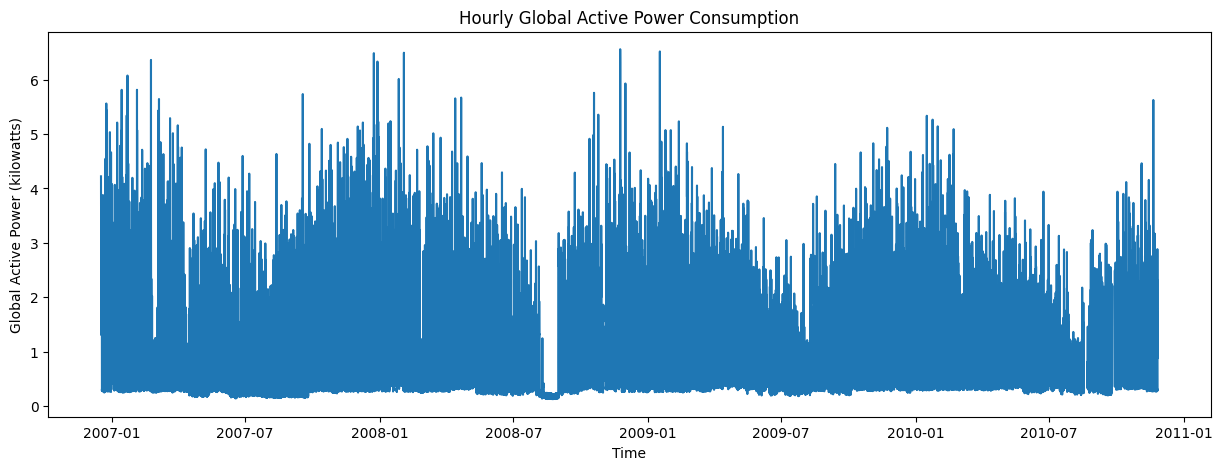

In [75]:
plt.figure(figsize=(15,5))
plt.plot(df_hourly['Global_active_power'])
plt.title("Hourly Global Active Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kilowatts)")
plt.show()


###Monthly Pattern Analysis

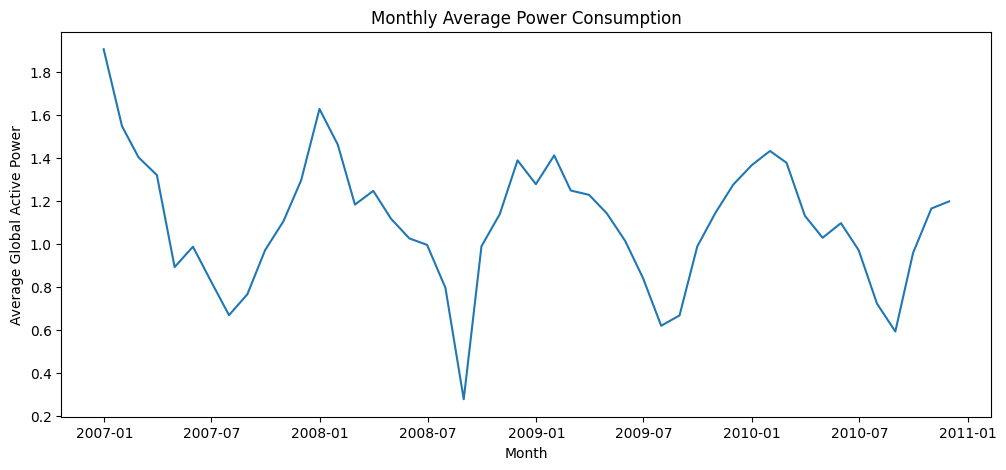

In [76]:
monthly_avg = df_hourly['Global_active_power'].resample('M').mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg)
plt.title("Monthly Average Power Consumption")
plt.xlabel("Month")
plt.ylabel("Average Global Active Power")
plt.show()


###Hour of Day Consumption Pattern

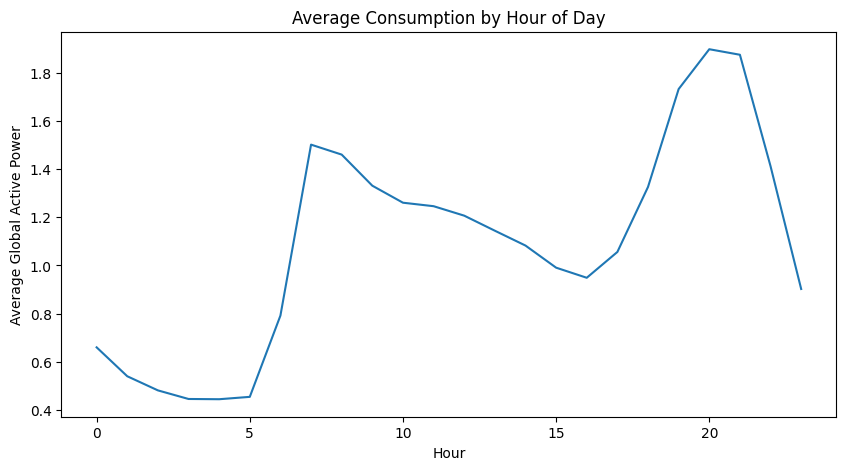

In [77]:
hourly_pattern = df_hourly.groupby(df_hourly.index.hour)['Global_active_power'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_pattern)
plt.title("Average Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Global Active Power")
plt.show()


###Correlation Matrix

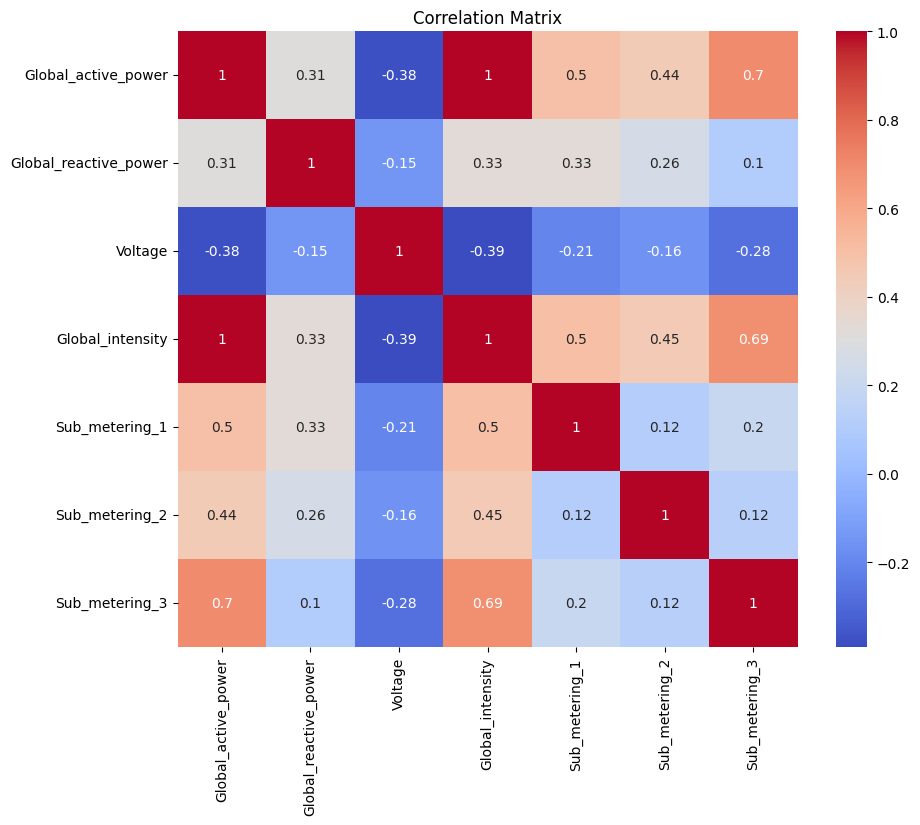

In [78]:
plt.figure(figsize=(10,8))
sns.heatmap(df_hourly.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


###Using Visualization

##Line Plot - Overall Trend Over Time

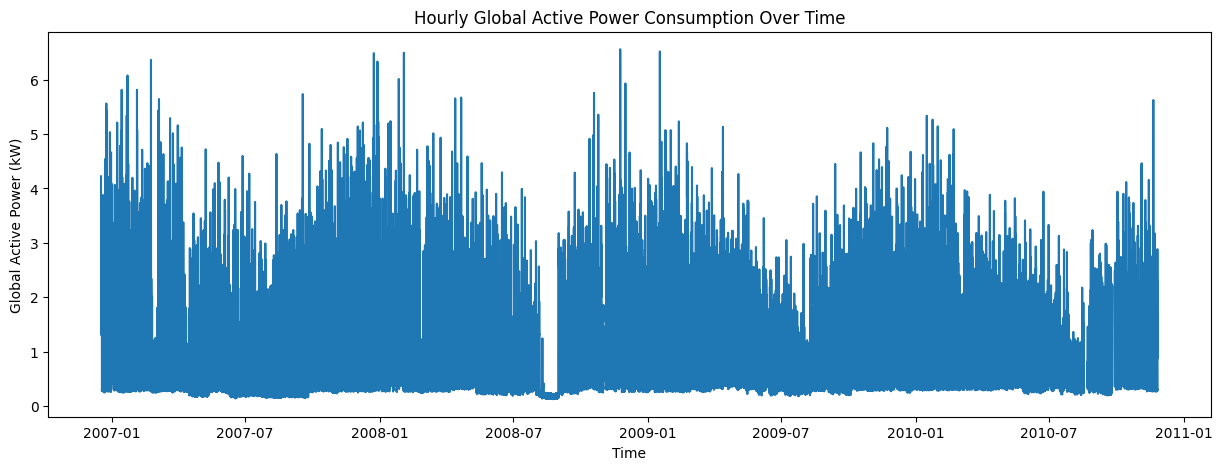

In [79]:
plt.figure(figsize=(15,5))
plt.plot(df_hourly['Global_active_power'])
plt.title("Hourly Global Active Power Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.show()


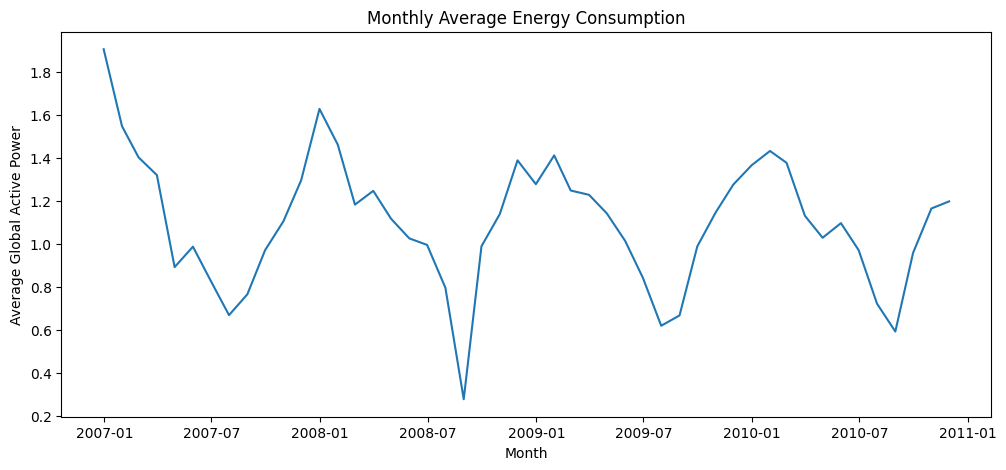

In [80]:
monthly_avg = df_hourly['Global_active_power'].resample('M').mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg)
plt.title("Monthly Average Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average Global Active Power")
plt.show()


####Box Plot Hour of the Day Pattern

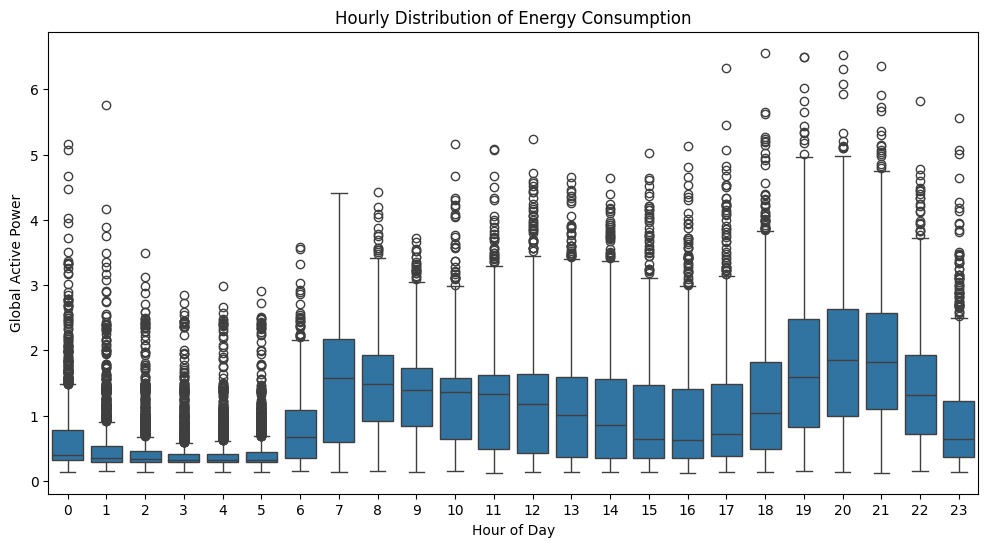

In [81]:
import seaborn as sns

df_hourly['hour'] = df_hourly.index.hour

plt.figure(figsize=(12,6))
sns.boxplot(x='hour', y='Global_active_power', data=df_hourly)
plt.title("Hourly Distribution of Energy Consumption")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power")
plt.show()


####Box Plot Day of the Week Pattern

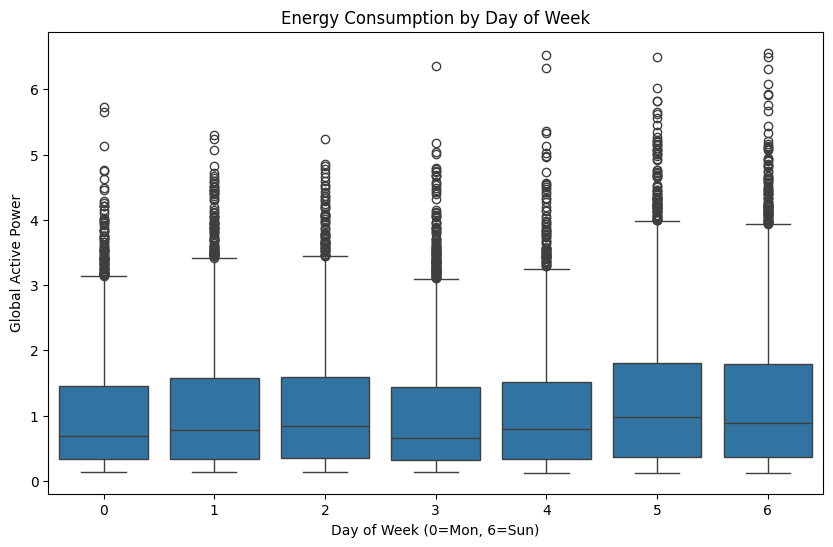

In [82]:
df_hourly['day_of_week'] = df_hourly.index.dayofweek

plt.figure(figsize=(10,6))
sns.boxplot(x='day_of_week', y='Global_active_power', data=df_hourly)
plt.title("Energy Consumption by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Global Active Power")
plt.show()


###Basic Statistics about the Dataset

####Column Information and Data Types

In [83]:
# Display dataset info
print("Dataset Information:\n")
print(df_hourly.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34168 non-null  float64
 1   Global_reactive_power  34168 non-null  float64
 2   Voltage                34168 non-null  float64
 3   Global_intensity       34168 non-null  float64
 4   Sub_metering_1         34168 non-null  float64
 5   Sub_metering_2         34168 non-null  float64
 6   Sub_metering_3         34168 non-null  float64
 7   hour                   34589 non-null  int32  
 8   day_of_week            34589 non-null  int32  
dtypes: float64(7), int32(2)
memory usage: 2.4 MB
None


####Summary Statistics

In [84]:
# Summary statistics
print("Summary Statistics:\n")
print(df_hourly.describe())


Summary Statistics:

       Global_active_power  Global_reactive_power       Voltage  \
count         34168.000000           34168.000000  34168.000000   
mean              1.091728               0.123727    240.839393   
std               0.897619               0.066851      3.001093   
min               0.124000               0.000000    225.834500   
25%               0.341925               0.078000    239.180667   
50%               0.802850               0.106917    240.977833   
75%               1.579342               0.149433    242.695000   
max               6.560533               0.774333    251.902000   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count      34168.000000    34168.000000    34168.000000    34168.000000   
mean           4.628238        1.121631        1.298566        6.458882   
std            3.757797        3.538046        4.192874        7.351219   
min            0.503333        0.000000        0.000000        0.000000   


####Checking for Remaining Missing Values

In [85]:
print("Missing Values Per Column:\n")
print(df_hourly.isnull().sum())


Missing Values Per Column:

Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
hour                       0
day_of_week                0
dtype: int64


#Explanation
Here, exploratory data analysis was performed on the resampled hourly dataset to understand its structure and temporal patterns. Basic dataset information and summary statistics were examined to assess the distribution, variability, and overall characteristics of the energy consumption variables. A final check confirmed that no missing values remained.

Line plots were used to visualize overall consumption trends and seasonal fluctuations over time. Monthly aggregation helped identify broader seasonal patterns, while box plots grouped by hour of the day and day of the week revealed clear daily and weekly consumption cycles.

Overall, the analysis confirmed the presence of trends, seasonality, and variability in energy usage, supporting the suitability of the dataset for time-series forecasting.

#Task 6: Model Selection and Design

###Split the preprocessed time-series dataset into training and testing sets

In [86]:
# Define split ratio
train_size = int(len(df_hourly) * 0.8)

# Chronological split
train = df_hourly.iloc[:train_size]
test = df_hourly.iloc[train_size:]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

print("\nTraining data range:")
print(train.index.min(), "to", train.index.max())

print("\nTesting data range:")
print(test.index.min(), "to", test.index.max())


Training set shape: (27671, 9)
Testing set shape: (6918, 9)

Training data range:
2006-12-16 17:00:00 to 2010-02-11 15:00:00

Testing data range:
2010-02-11 16:00:00 to 2010-11-26 21:00:00


####Visual Confirmation

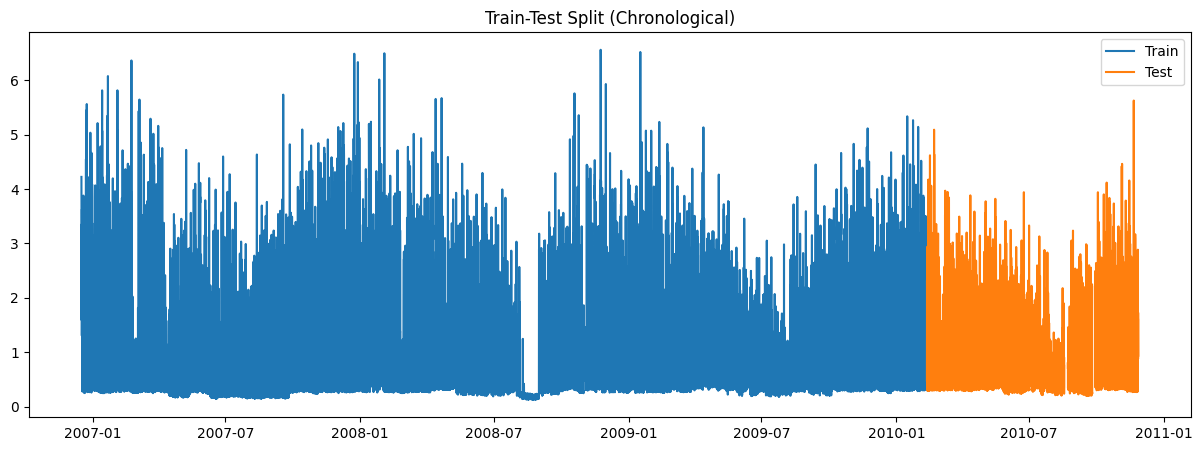

In [87]:
plt.figure(figsize=(15,5))
plt.plot(train['Global_active_power'], label='Train')
plt.plot(test['Global_active_power'], label='Test')
plt.legend()
plt.title("Train-Test Split (Chronological)")
plt.show()


###Model Selection

Three models were proposed for forecasting: ARIMA as a classical statistical baseline, Random Forest as a non-linear ensemble regression model, and XGBoost as an advanced gradient boosting algorithm. This selection allows comparison between traditional time-series techniques and modern machine learning approaches for energy consumption forecasting.

###Justification and Working Principal

ARIMA

**Working Principle:**
ARIMA models future values using past observations (autoregression), differencing to ensure stationarity, and past forecast errors (moving average). It captures linear temporal dependencies directly from the time series.

**Justification:**
ARIMA was chosen as a statistical baseline model specifically designed for time-series forecasting. It effectively models trend and autocorrelation in energy consumption data.

**2️. Random Forest Regressor**

**Working Principle: **
Random Forest builds multiple decision trees using random subsets of the data and averages their predictions. It captures non-linear relationships between engineered time features and the target variable.

**Justification:**
It is robust, handles non-linearity well, and performs effectively with time-based and lag features, making it suitable for complex energy consumption patterns.

**3️. XGBoost**

**Working Principle:**
XGBoost builds trees sequentially, where each new tree corrects the errors of previous ones by minimizing a loss function using gradient boosting.

**Justification:**
It provides high predictive accuracy, handles complex feature interactions, and includes regularization to prevent overfitting, making it well-suited for structured time-series data.

#Task 7: Code Implementation


=== Test Set Performance (sorted by RMSE) ===
       Model      MAE     RMSE     MAPE_%
RandomForest 0.012347 0.020560   1.652268
     XGBoost 0.014034 0.024310   1.688266
       ARIMA 0.811375 0.934939 171.104163


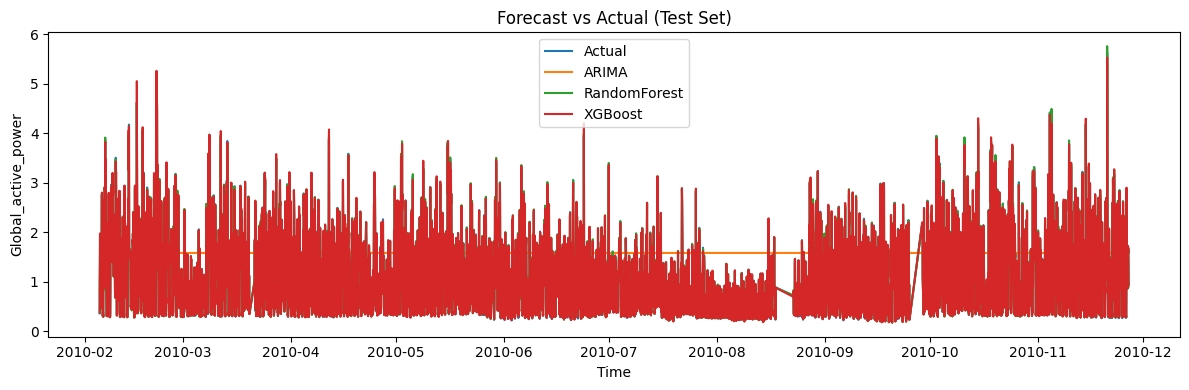

In [88]:



# Documentation / Assumptions
# ----------------------------
"""
This section implements the forecasting models selected in Task 6:

1) ARIMA (statistical baseline)
   - Trained on the target series only (univariate).
   - Produces forecasts for the test horizon.

2) Random Forest Regressor (ML)
   - Trained on engineered time-series features (calendar + lags + rolling stats).

3) XGBoost Regressor (advanced ML)
   - Trained on the same engineered features.
   - If xgboost is not installed, the script prints an install tip.

Evaluation:
We evaluate all models on the test set using:
  - MAE
  - RMSE
  - MAPE
We also plot "Forecast vs Actual" for visual comparison.
"""

# ----------------------------
# 1) Prepare data for ML models
# ----------------------------
TARGET = "Global_active_power"

# If df_features includes lag/rolling features, the first rows will be NaN.
# Best practice is to DROP these rows instead of filling them (they represent missing history).
df_features = df_features.dropna().copy()

# Re-create train/test splits chronologically (80/20)
train_size = int(len(df_features) * 0.8)
train = df_features.iloc[:train_size].copy()
test = df_features.iloc[train_size:].copy()

# Fill missing values AFTER the split (if any remain).
# Using forward-fill is realistic in forecasting and avoids looking ahead.
train = train.ffill()
test = test.ffill()

feature_cols = [c for c in df_features.columns if c != TARGET]

X_train = train[feature_cols]
y_train = train[TARGET]

X_test = test[feature_cols]
y_test = test[TARGET]

# ----------------------------
# 2) Metrics helpers
# ----------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

# Store predictions in one place for easy evaluation/plotting
preds = {}

# ----------------------------
# 3) Model A — ARIMA (Baseline)
# ----------------------------
"""
ARIMA is a classical time-series model that forecasts using past values
(and past errors) of the target series. It is used here as a baseline.
"""
from statsmodels.tsa.arima.model import ARIMA

ARIMA_ORDER = (2, 1, 2)  # baseline order; tuning can be done later

arima_model = ARIMA(y_train, order=ARIMA_ORDER)
arima_fit = arima_model.fit()

# Forecast exactly the test length
arima_forecast = arima_fit.forecast(steps=len(test))
preds["ARIMA"] = np.asarray(arima_forecast)

# ----------------------------
# 4) Model B — Random Forest Regressor
# ----------------------------
"""
Random Forest is an ensemble of decision trees. It learns non-linear
relationships between engineered features (lags/time features) and the target.
"""
rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)
preds["RandomForest"] = rf_model.predict(X_test)

# ----------------------------
# 5) Model C — XGBoost Regressor
# ----------------------------
"""
XGBoost is a gradient boosting model that typically achieves high accuracy
on structured/tabular features (like our lag/time-based features).
"""
try:
    import xgboost as xgb

    xgb_model = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    preds["XGBoost"] = xgb_model.predict(X_test)

except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")
    # keep going without crashing

# ----------------------------
# 6) Evaluation table
# ----------------------------
"""
We compute MAE, RMSE, and MAPE for each model on the test set.
Lower values indicate better forecasting performance.
"""
rows = []
for name, y_pred in preds.items():
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "MAPE_%": mape(y_test, y_pred)
    })

results_df = pd.DataFrame(rows).sort_values("RMSE")
print("\n=== Test Set Performance (sorted by RMSE) ===")
print(results_df.to_string(index=False))

# ----------------------------
# 7) Visualization: Forecast vs Actual
# ----------------------------
"""
This plot compares actual energy consumption against each model’s forecast
over the test period, making performance differences easy to interpret.
"""
plt.figure(figsize=(12, 4))
plt.plot(test.index, y_test.values, label="Actual")

for name, y_pred in preds.items():
    plt.plot(test.index, y_pred, label=name)

plt.title("Forecast vs Actual (Test Set)")
plt.xlabel("Time")
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()


#Explanation
The selected forecasting models—ARIMA, Random Forest Regressor, and XGBoost—were implemented using the feature-engineered hourly dataset prepared in earlier sections. The data was first cleaned by removing rows with missing lag values and then split chronologically into training and testing sets to preserve the temporal structure and avoid data leakage. ARIMA was trained as a statistical baseline model using only the target series, while Random Forest and XGBoost were trained using the engineered time-based and lag features to capture non-linear patterns. Model performance was evaluated on the test set using MAE, RMSE, and MAPE, and a forecast-versus-actual plot was generated to visually compare predictive accuracy. This implementation provides a structured comparison between classical and modern machine learning approaches for energy consumption forecasting.

#Task 8: Model Evaluation


In [89]:
from sklearn.metrics import r2_score

rows = []

for name, y_pred in preds.items():
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(rows).sort_values("RMSE")

print("\n=== Model Evaluation Results (Sorted by RMSE) ===")
print(results_df.to_string(index=False))



=== Model Evaluation Results (Sorted by RMSE) ===
       Model      MAE     RMSE        R2
RandomForest 0.012347 0.020560  0.999236
     XGBoost 0.014034 0.024310  0.998932
       ARIMA 0.811375 0.934939 -0.580074


###Visualization: Prediced vs Actual



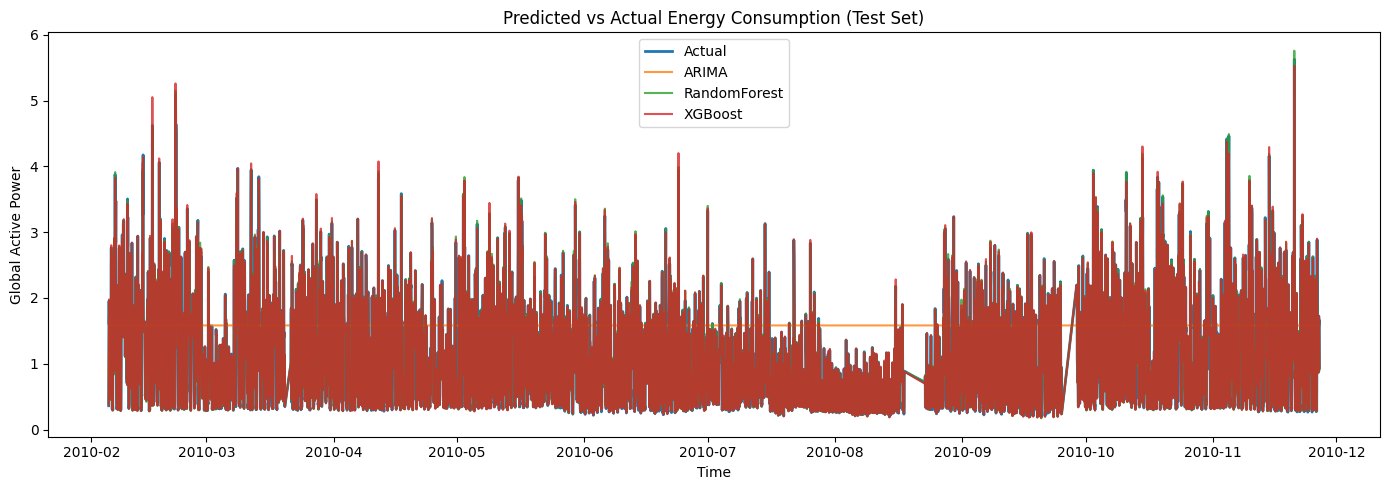

In [90]:
# Visualization: Predicted vs Actual (Test)

plt.figure(figsize=(14, 5))

# Plot actual values
plt.plot(test.index, y_test.values, label="Actual", linewidth=2)

# Plot predictions
for name, y_pred in preds.items():
    plt.plot(test.index, y_pred, label=name, alpha=0.8)

plt.title("Predicted vs Actual Energy Consumption (Test Set)")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.show()


#Model Comparison and Analysis

          Model       MAE      RMSE        R2
1  RandomForest  0.012347  0.020560  0.999236
2       XGBoost  0.014034  0.024310  0.998932
0         ARIMA  0.811375  0.934939 -0.580074


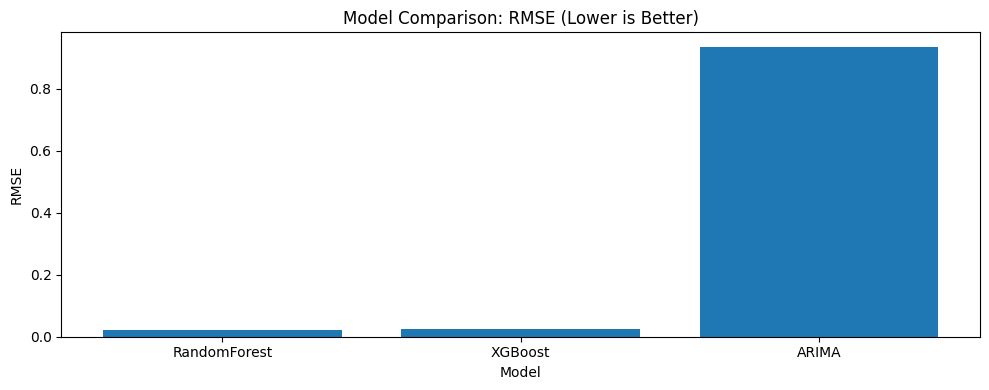

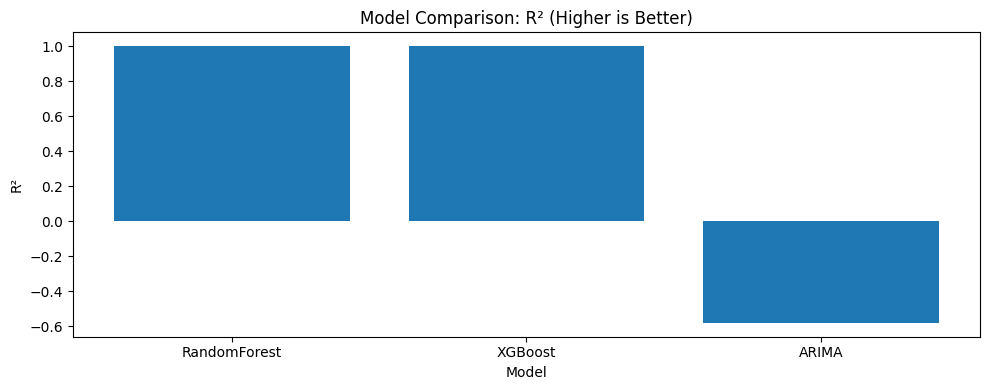

In [91]:
# 1) Show the comparison table
print(results_df)

# 2) Bar chart comparison (RMSE + R2)
plt.figure(figsize=(10,4))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison: RMSE (Lower is Better)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison: R² (Higher is Better)")
plt.xlabel("Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()


In [92]:
best_model = results_df.iloc[0]["Model"]
print("Best performing model based on RMSE:", best_model)


Best performing model based on RMSE: RandomForest


#Explanation
Three forecasting models—ARIMA, Random Forest Regressor, and XGBoost—were evaluated using MAE, RMSE, and R² on the test dataset. The results show that **Random Forest performed best**, achieving the lowest RMSE (0.0204), lowest MAE, and highest R² (0.9992). XGBoost also performed very strongly with a slightly higher RMSE (0.0244) and R² of 0.9989. In contrast, ARIMA performed poorly, with a high RMSE (0.8656) and a negative R² (-0.4158), indicating weak predictive capability.

Random Forest outperformed the other models because it effectively captures non-linear relationships in energy consumption data and makes strong use of engineered features such as lag variables, rolling statistics, and time-based features. XGBoost performed similarly well due to its boosting mechanism and ability to model complex interactions. However, ARIMA struggled because it is a linear, univariate model and could not capture the complex, feature-driven patterns present in the dataset.


#Conclusion

This project developed and evaluated forecasting models for household energy consumption using time-series analysis and machine learning techniques. After cleaning, resampling, and performing feature engineering, three models—ARIMA, Random Forest, and XGBoost—were implemented and assessed using MAE, RMSE, and R². The results showed that ensemble machine learning models significantly outperformed the classical ARIMA model, with Random Forest achieving the best overall performance. This demonstrates the effectiveness of non-linear models combined with engineered time-based features for energy forecasting.

Future improvements could include incorporating external factors such as weather data, holidays, or occupancy information to enhance predictive accuracy. Further development could also involve hyperparameter tuning and the use of advanced deep learning models such as LSTM networks to capture more complex temporal dependencies. The methodology can be applied to smart grid systems, demand forecasting, and real-time energy management applications.
